# gubapost(股吧帖子) 语料 — activation rank 描述性分析

在 **gubapost** 语料(2020–2023 采样)上重做无标签激活几何审计:
12 层 attention output 的 coverage / 特征值谱 / 有效维度 / 子空间。

**与旧研报语料 run 完全隔离**: 配置 `configs/activation_rank_guba.yaml`,
产物写入 `artifacts/checkpoint_activation_rank/runs/gubapost_v1/`。

**输入**: `artifacts/gubapost_baseline/gubapost_text_sample.parquet`
(由 `scripts/sample_gubapost_text.py` 预生成, ~44 万帖采样)。

**GPU**: 默认 `cuda:1`(物理 GPU 1)。**确保 kernel 的 `CUDA_VISIBLE_DEVICES` 未设置**
(否则 cuda:1 不指向物理 GPU 1; 若已设为 1, 需在 cell 0 前设
`os.environ['ACTIVATION_RANK_DEVICE']='cuda:0'`)。

**运行**: 自上而下执行 cell 0→11, 约 20–30 min。断点续跑: 已完成的 stage 自动跳过。

In [1]:
# 1. 导入模块、读取配置和路径
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

_base = Path('/home/intern_fjq_2026').resolve()
_current = Path.cwd().resolve()
_candidates = [
    _base / 'Projects' / 'chinese-wwm-roberta',
    _base.parent / 'intern_fjq_2026' / 'Projects' / 'chinese-wwm-roberta',
    _current,
    _current.parent,
]
ROOT = next((path for path in _candidates if (path / 'src').is_dir()), None)
assert ROOT is not None, 'Repository root was not found'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.activation_rank import (
    finalize_activation_rank_run,
    load_activation_rank_config,
    plot_rank_curves,
    plot_rank_heatmap,
    preflight_activation_rank,
    run_pilot_stage,
    run_rank_analysis_stage,
    run_rank_shards_stage,
    run_sample_stage,
    run_wo_mechanism_stage,
    validate_pilot_outputs,
    validate_rank_analysis_outputs,
    validate_wo_mechanism_outputs,
)

CONFIG_PATH = ROOT / 'configs' / 'activation_rank_guba.yaml'
config = load_activation_rank_config(CONFIG_PATH)
RUN_DIR = Path(config['output']['run_directory']).expanduser().resolve()
display({'config': str(CONFIG_PATH), 'run_directory': str(RUN_DIR)})

{'config': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/configs/activation_rank_guba.yaml',
 'run_directory': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/gubapost_v1'}

In [2]:
# 2. 服务器、GPU、磁盘、checkpoint与文本preflight
preflight = preflight_activation_rank(config)
display(preflight)
assert preflight['status'].eq('ok').all(), preflight

,check,status,detail
0,text,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
1,checkpoint,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
2,tokenizer,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
3,disk_budget,ok,"{""estimated_peak"": 6442450944, ""free"": 6105546..."
4,cpu_runtime,ok,"{""configured_threads"": 8, ""effective_threads"":..."
5,gpu_runtime,ok,"{""requested_device"": ""cuda:1"", ""cuda"": true, ""..."


In [3]:
# 3. 构建或严格复用sample manifest
sample_dir = run_sample_stage(config)
sample_manifest = pd.read_parquet(sample_dir / 'sample_manifest.parquet')
display(sample_manifest.head())
display(sample_manifest.groupby('shard')['token_count'].agg(['count', 'sum']))

,sample_row,source_row,report_id,text_sha256,stable_order,shard,token_count,is_unique_text
0,0,167013,1056643234,962b421b95e7d3d743371881c1e61f1234b224a6f05d1a...,27355877955246,6,251,True
1,1,282060,1212060258,1559ce817c4febe03b6f8a3fbe044ab1c04a6091212000...,53066046616481,1,45,True
2,2,353068,1289031874,0f54e92885dedb127a64b5580890533775aef2abb4a708...,102359656144911,7,492,True
3,3,129054,1009853064,3a177ac792ed303f4cdd2e63b7e0c9fb92ed7a0c0058b7...,234614247796826,2,151,True
4,4,252752,1170945867,3c572953fccf60c5d9242f15064563f6ad299be07c0a6a...,288205749350173,5,68,True


,count,sum
shard,,
0,19231,1250392
1,19385,1250006
2,19443,1250124
3,19101,1250071
4,19359,1250118
5,19069,1250021
6,18775,1250006
7,19151,1250075


In [4]:
# 4. hooks、精度、batch size与吞吐pilot
pilot_dir = run_pilot_stage(config)
pilot_manifest = validate_pilot_outputs(pilot_dir)
display(pd.Series(pilot_manifest))
display(pd.read_parquet(pilot_dir / 'batch_benchmark.parquet'))
display(pd.read_parquet(pilot_dir / 'precision_metrics.parquet'))

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


schema_version                                        activation_rank_pilot_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             8fce195ea02f536789e106d1f2af02f2617b8b114eb136...
config_sha256                  f7a5122f776771347b8bc738c5d7b172ea8dd896fb9f98...
max_length                                                                   512
git_commit                              be0f9437fce1c9d7d635af92e9bacf6f68ddcb84
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                305b9335b883e706c84b40135874ed18b994b2325cd7b5...
created_at                                                   2026-09-03T10:06:02
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
pilot_valid_tokens          

,batch_size,status,peak_memory_bytes,total_memory_bytes,headroom_fraction,checksum,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio
0,64,ok,712474624,85043904512,0.991622,93030.085014,128,8782,5,0.871621,10075.479218,0.249834
1,128,ok,1222424576,85043904512,0.985626,196164.618017,256,18498,5,0.471384,39241.900331,0.250985
2,256,ok,2065167872,85043904512,0.975716,383039.431976,512,36688,5,0.891231,41165.527061,0.260984
3,512,ok,3383695872,85043904512,0.960212,704758.445193,1024,68078,5,1.802096,37777.124369,0.284589


,dtype,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio,peak_memory_bytes,maximum_normalized_erank_difference,maximum_k99_difference,maximum_relative_spectrum_difference_above_1pct,passed
0,float32,7631,500483,32,10.352970,48341.971121,0.102793,10457256448,0.000000,0,0.000000,True
1,float16,7631,500483,32,4.772727,104863.102619,0.102793,5473986560,0.000126,0,0.001541,True
2,bfloat16,7631,500483,32,4.677411,107000.015372,0.102793,5473986560,0.001237,1,0.017238,False


In [5]:
# 5. 运行缺失的rank shards；已验证分片自动跳过
# kernel重启或某一shard失败后，只需重跑cell 1与本cell。
try:
    moments_dir = run_rank_shards_stage(config)
except RuntimeError:
    audit_candidates = [RUN_DIR / 'moments' / 'norm_audit_5m.parquet', RUN_DIR / 'moments' / 'norm_audit.parquet']
    for audit_path in audit_candidates:
        if audit_path.is_file():
            display(pd.read_parquet(audit_path).sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))
    raise
moments_manifest = json.loads((moments_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(moments_manifest))
display(pd.DataFrame(moments_manifest['norm_audit']['failed_blocking_positions']))
norm_audit = pd.read_parquet(moments_dir / 'norm_audit.parquet')
display(norm_audit.sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))

schema_version                                        activation_rank_shard_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             8fce195ea02f536789e106d1f2af02f2617b8b114eb136...
config_sha256                  f7a5122f776771347b8bc738c5d7b172ea8dd896fb9f98...
max_length                                                                   512
git_commit                              be0f9437fce1c9d7d635af92e9bacf6f68ddcb84
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                305b9335b883e706c84b40135874ed18b994b2325cd7b5...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          256
norm_thresholds_sha256      

""


,population,site,blocking,compute_dtype,dtype_epsilon,pilot_count,main_count,pilot_mean,main_mean,pilot_std,...,relative_norm_std_shift,filtered_count,filtered_fraction,mean_tolerance,std_tolerance,filtered_fraction_tolerance,mean_passed,std_passed,filtered_passed,position_passed
25,token,attention_output_01,True,float16,0.000977,500483,10000813,9.946670,9.939056,1.580318,...,0.009291,3169,0.000317,0.01,0.05,0.01,True,True,True,True
26,token,attention_output_02,True,float16,0.000977,500483,10000813,10.046584,10.036011,1.639578,...,0.001435,0,0.000000,0.01,0.05,0.01,True,True,True,True
27,token,attention_output_03,True,float16,0.000977,500483,10000813,8.408532,8.400434,1.700101,...,0.001790,86,0.000009,0.01,0.05,0.01,True,True,True,True
28,token,attention_output_04,True,float16,0.000977,500483,10000813,8.383322,8.380943,1.644140,...,0.000291,15,0.000001,0.01,0.05,0.01,True,True,True,True
29,token,attention_output_05,True,float16,0.000977,500483,10000813,7.672210,7.669828,1.879216,...,0.003421,25,0.000002,0.01,0.05,0.01,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,cls,z_08,False,float16,0.000977,7631,153514,1.692629,1.691772,0.084082,...,0.023224,93,0.000606,0.01,0.05,0.01,True,True,True,True
70,cls,z_09,False,float16,0.000977,7631,153514,1.348421,1.347321,0.072469,...,0.010167,4,0.000026,0.01,0.05,0.01,True,True,True,True
71,cls,z_10,False,float16,0.000977,7631,153514,1.776326,1.775751,0.101816,...,0.004909,30,0.000195,0.01,0.05,0.01,True,True,True,True
72,cls,z_11,False,float16,0.000977,7631,153514,2.139640,2.137337,0.196057,...,0.012421,106,0.000690,0.01,0.05,0.01,True,True,True,True


In [6]:
# 6. 合并moments、FP64特征分解与稳定性/坍缩分析
analysis_dir = run_rank_analysis_stage(config)
display(pd.Series(validate_rank_analysis_outputs(analysis_dir)))
rank_metrics = pd.read_parquet(analysis_dir / 'rank_metrics.parquet')
compression_metrics = pd.read_parquet(analysis_dir / 'compression_metrics.parquet')
display(rank_metrics)
display(compression_metrics)

schema_version                                     activation_rank_analysis_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             8fce195ea02f536789e106d1f2af02f2617b8b114eb136...
config_sha256                  f7a5122f776771347b8bc738c5d7b172ea8dd896fb9f98...
max_length                                                                   512
git_commit                              be0f9437fce1c9d7d635af92e9bacf6f68ddcb84
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                305b9335b883e706c84b40135874ed18b994b2325cd7b5...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          256
norm_thresholds_sha256      

,stream,site,kind,layer,count,effective_rank,normalized_effective_rank,stable_rank,k90_variance,k95_variance,k99_variance,directions_above_1pct_max,dimension
0,token_natural_filtered,residual_00,residual,0,10000813,629.360631,0.819480,46.050004,398,506,656,765,768
1,token_natural_filtered,residual_01,residual,1,10000813,635.471749,0.827437,45.764728,397,510,671,767,768
2,token_natural_filtered,residual_02,residual,2,10000813,649.550022,0.845768,41.799007,422,537,689,767,768
3,token_natural_filtered,residual_03,residual,3,10000813,656.366297,0.854644,38.011923,438,552,699,767,768
4,token_natural_filtered,residual_04,residual,4,10000813,653.572002,0.851005,30.995842,437,554,702,767,768
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,token_unique_filtered,mlp_output_08,mlp_output,8,9976050,669.089178,0.871210,33.774249,453,560,701,768,768
241,token_unique_filtered,mlp_output_09,mlp_output,9,9976863,669.841241,0.872189,36.828310,454,561,701,768,768
242,token_unique_filtered,mlp_output_10,mlp_output,10,9977282,655.991113,0.854155,28.702353,429,542,696,768,768
243,token_unique_filtered,mlp_output_11,mlp_output,11,9977262,645.993131,0.841137,35.237415,419,533,688,768,768


,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.682447,0.682385,0.682506,0.623636,0.623456,0.623827,0.624532,0.624370,0.624705,clear_collapse
1,2,0.724396,0.724309,0.724479,0.629198,0.629069,0.629324,0.638389,0.638261,0.638515,clear_collapse
2,3,0.743117,0.743035,0.743194,0.706412,0.706280,0.706530,0.715474,0.715349,0.715601,clear_collapse
3,4,0.736917,0.736781,0.737059,0.681001,0.680941,0.681065,0.696650,0.696522,0.696758,clear_collapse
4,5,0.765609,0.765483,0.765749,0.701862,0.701794,0.701938,0.710355,0.710278,0.710452,clear_collapse
5,6,0.766973,0.766897,0.767057,0.742070,0.742000,0.742148,0.758475,0.758389,0.758562,clear_collapse
6,7,0.775392,0.775342,0.775434,0.728691,0.728537,0.728829,0.746398,0.746271,0.746504,clear_collapse
7,8,0.821759,0.821615,0.821893,0.741236,0.741148,0.741329,0.759945,0.759818,0.760064,clear_collapse
8,9,0.783173,0.783112,0.783243,0.757851,0.757685,0.758030,0.775185,0.775062,0.775304,clear_collapse
9,10,0.802104,0.802004,0.802205,0.767161,0.766898,0.767451,0.769468,0.769274,0.769699,clear_collapse


In [7]:
# 7. W^O协方差恒等式、方向分解与反事实机制分析
mechanism_dir = run_wo_mechanism_stage(config)
display(pd.Series(validate_wo_mechanism_outputs(mechanism_dir)))
display(pd.read_parquet(mechanism_dir / 'wo_summary.parquet'))
display(pd.read_parquet(mechanism_dir / 'wo_mechanism.parquet').head(24))

schema_version                                 activation_rank_wo_mechanism_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             8fce195ea02f536789e106d1f2af02f2617b8b114eb136...
config_sha256                  f7a5122f776771347b8bc738c5d7b172ea8dd896fb9f98...
max_length                                                                   512
git_commit                              be0f9437fce1c9d7d635af92e9bacf6f68ddcb84
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                305b9335b883e706c84b40135874ed18b994b2325cd7b5...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          256
norm_thresholds_sha256      

,layer,covariance_relative_frobenius_error,observed_learned_wo_effective_rank,observed_learned_wo_normalized_effective_rank,observed_learned_wo_k99_variance,polar_orthogonal_scaled_effective_rank,polar_orthogonal_scaled_normalized_effective_rank,polar_orthogonal_scaled_k99_variance,random_orthogonal_scaled_effective_rank,random_orthogonal_scaled_normalized_effective_rank,random_orthogonal_scaled_k99_variance,wo_only_isotropic_input_effective_rank,wo_only_isotropic_input_normalized_effective_rank,wo_only_isotropic_input_k99_variance,covariance_identity_tolerance,covariance_identity_passed
0,1,0.000206,396.977064,0.516897,388,581.771957,0.757516,627,581.771957,0.757516,627,574.900814,0.748569,562,0.005,True
1,2,0.000238,414.783188,0.540082,392,572.669431,0.745663,599,572.669431,0.745663,599,571.279495,0.743854,554,0.005,True
2,3,0.000240,469.662551,0.611540,463,632.041517,0.822971,668,632.041517,0.822971,668,582.022475,0.757842,557,0.005,True
3,4,0.000241,455.425645,0.593002,447,618.058467,0.804764,661,618.058467,0.804764,661,572.478791,0.745415,554,0.005,True
4,5,0.000279,464.978568,0.605441,457,607.381376,0.790861,666,607.381376,0.790861,666,573.124933,0.746256,551,0.005,True
5,6,0.000260,494.992668,0.644522,484,645.410020,0.840378,697,645.410020,0.840378,697,581.801080,0.757553,555,0.005,True
6,7,0.000248,488.182957,0.635655,482,629.615957,0.819812,675,629.615957,0.819812,675,596.939284,0.777265,566,0.005,True
7,8,0.000303,498.091484,0.648557,494,604.212583,0.786735,644,604.212583,0.786735,644,597.845947,0.778445,570,0.005,True
8,9,0.000276,507.862944,0.661280,508,648.500020,0.844401,704,648.500020,0.844401,704,600.116044,0.781401,576,0.005,True
9,10,0.000283,503.602282,0.655732,504,627.886555,0.817561,701,627.886555,0.817561,701,601.153587,0.782752,573,0.005,True


,layer,component,attention_output_eigenvalue,z_directional_variance,wo_scale_squared,factor_product
0,1,1,7.237621,1.695217,4.269428,7.237606
1,1,2,4.011137,0.955768,4.196743,4.011113
2,1,3,2.959472,0.635096,4.659901,2.959484
3,1,4,2.236356,0.531276,4.209419,2.236364
4,1,5,1.882496,0.415582,4.529865,1.882529
5,1,6,1.840245,0.457374,4.023511,1.840251
6,1,7,1.732716,0.461573,3.753926,1.732710
7,1,8,1.686428,0.431497,3.908349,1.686440
8,1,9,1.480890,0.362335,4.087143,1.480916
9,1,10,1.417977,0.286815,4.943878,1.417980


schema_version                                          activation_rank_run_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             8fce195ea02f536789e106d1f2af02f2617b8b114eb136...
config_sha256                  f7a5122f776771347b8bc738c5d7b172ea8dd896fb9f98...
max_length                                                                   512
git_commit                              be0f9437fce1c9d7d635af92e9bacf6f68ddcb84
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                305b9335b883e706c84b40135874ed18b994b2325cd7b5...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          256
norm_thresholds_sha256      

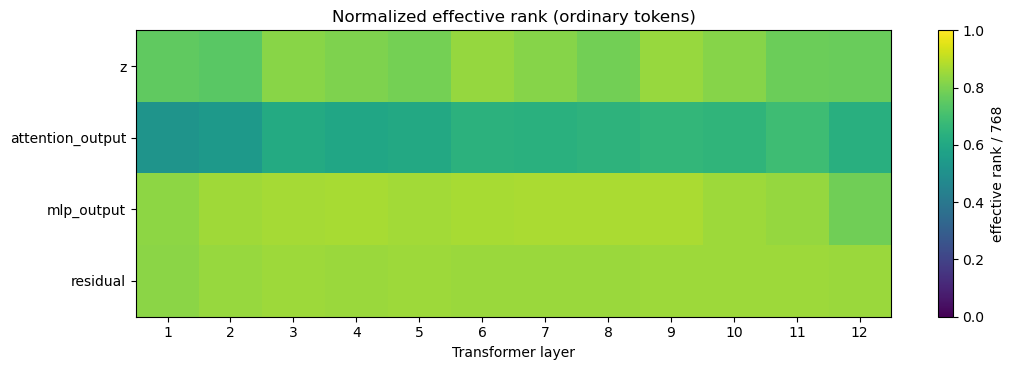

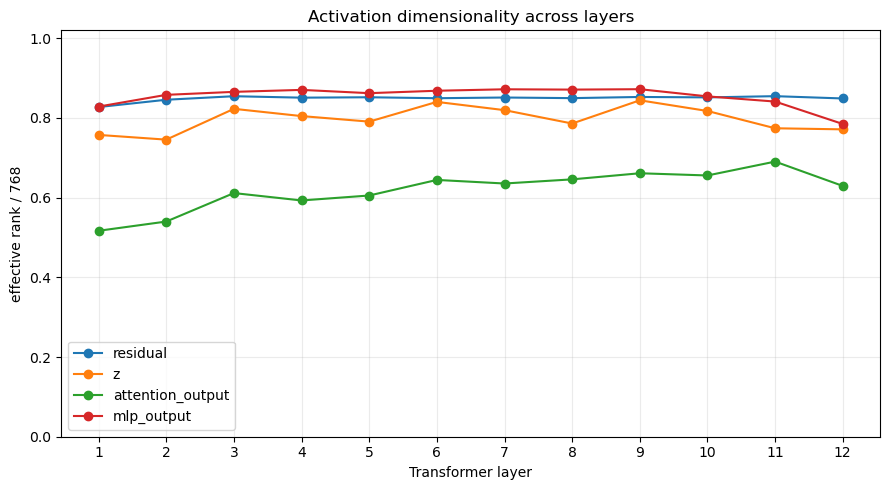

,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.682447,0.682385,0.682506,0.623636,0.623456,0.623827,0.624532,0.624370,0.624705,clear_collapse
1,2,0.724396,0.724309,0.724479,0.629198,0.629069,0.629324,0.638389,0.638261,0.638515,clear_collapse
2,3,0.743117,0.743035,0.743194,0.706412,0.706280,0.706530,0.715474,0.715349,0.715601,clear_collapse
3,4,0.736917,0.736781,0.737059,0.681001,0.680941,0.681065,0.696650,0.696522,0.696758,clear_collapse
4,5,0.765609,0.765483,0.765749,0.701862,0.701794,0.701938,0.710355,0.710278,0.710452,clear_collapse
5,6,0.766973,0.766897,0.767057,0.742070,0.742000,0.742148,0.758475,0.758389,0.758562,clear_collapse
6,7,0.775392,0.775342,0.775434,0.728691,0.728537,0.728829,0.746398,0.746271,0.746504,clear_collapse
7,8,0.821759,0.821615,0.821893,0.741236,0.741148,0.741329,0.759945,0.759818,0.760064,clear_collapse
8,9,0.783173,0.783112,0.783243,0.757851,0.757685,0.758030,0.775185,0.775062,0.775304,clear_collapse
9,10,0.802104,0.802004,0.802205,0.767161,0.766898,0.767451,0.769468,0.769274,0.769699,clear_collapse


In [8]:
# 8. 图表、结论表与最终run manifest
completed_dir = finalize_activation_rank_run(config)
final_manifest = json.loads((completed_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(final_manifest))
display(plot_rank_heatmap(completed_dir / 'analysis'))
display(plot_rank_curves(completed_dir / 'analysis'))
display(pd.read_parquet(completed_dir / 'compression_metrics.parquet'))

,effective_rank,normalized_erank,k90,k95,k99,dirs_above_1pct,dimension
kind,,,,,,,
attention_output,475.5,0.6,229.9,310.7,468.6,684.5,768
mlp_output,656.0,0.9,430.6,539.2,688.2,764.6,768
residual,652.2,0.8,434.1,553.0,701.9,767.0,768
z,612.8,0.8,368.5,485.1,661.2,768.0,768


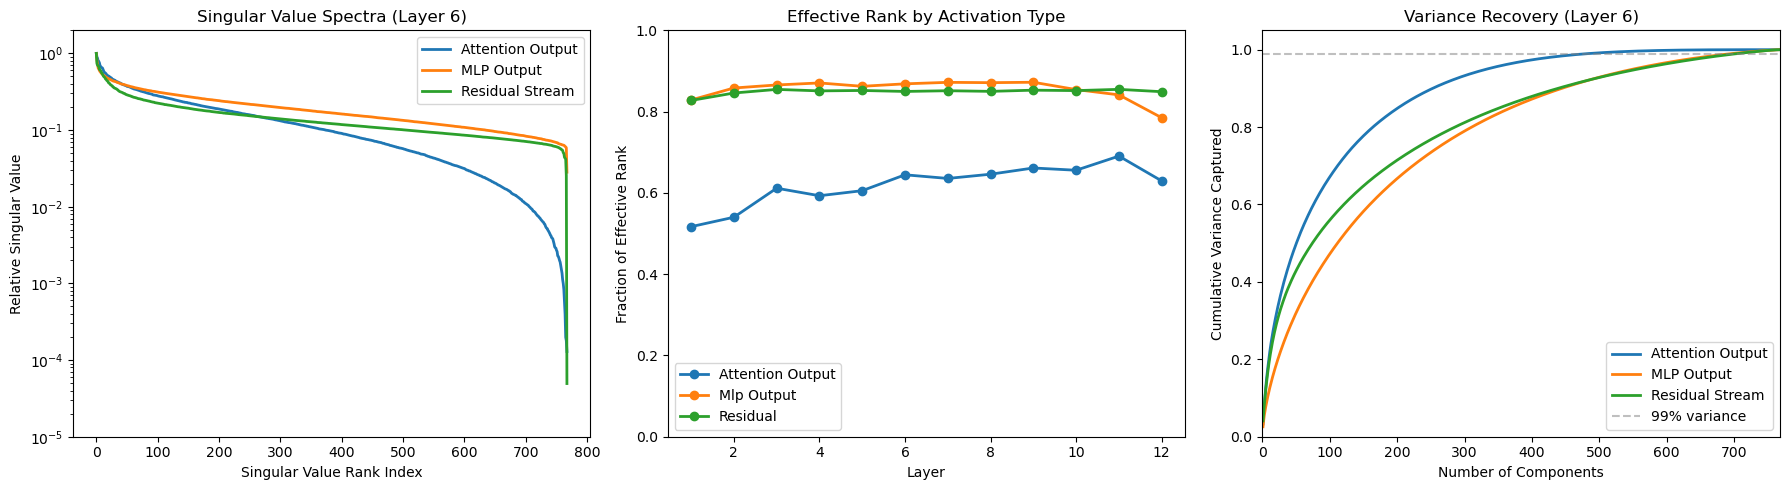


关键数值 (Layer 6):
  Attention Output    : dirs>1%=706/768 (91.9%), 99% var in 484/768 (63.0%)
  MLP Output          : dirs>1%=768/768 (100.0%), 99% var in 697/768 (90.8%)
  Residual Stream     : dirs>1%=767/768 (99.9%), 99% var in 705/768 (91.8%)


In [9]:
# 9. 谱衰减与有效维度对比 — 复现论文 Figure 3a
# 从已有 rank_metrics + subspaces 提取指标: attention_output vs MLP vs residual
import numpy as np
import matplotlib.pyplot as plt

try:
    completed_dir
except NameError:
    completed_dir = RUN_DIR

subspaces = np.load(completed_dir / 'analysis' / 'subspaces.npz', allow_pickle=False)
rank_metrics_full = pd.read_parquet(completed_dir / 'analysis' / 'rank_metrics.parquet')
rm = rank_metrics_full[rank_metrics_full['stream'] == 'token_natural_filtered'].copy()
rm_layers = rm[rm['layer'] > 0]

summary = rm_layers.groupby('kind').agg(
    effective_rank=('effective_rank', 'mean'),
    normalized_erank=('normalized_effective_rank', 'mean'),
    k90=('k90_variance', 'mean'),
    k95=('k95_variance', 'mean'),
    k99=('k99_variance', 'mean'),
    dirs_above_1pct=('directions_above_1pct_max', 'mean'),
    dimension=('dimension', 'first'),
).round(1)
display(summary)

layer = 6
sites = {
    'Attention Output': f'token_natural_filtered__attention_output_{layer:02d}',
    'MLP Output': f'token_natural_filtered__mlp_output_{layer:02d}',
    'Residual Stream': f'token_natural_filtered__residual_{layer:02d}',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左: 奇异值谱 (Figure 3a)
ax = axes[0]
for label, prefix in sites.items():
    eigvals = subspaces[f'{prefix}__eigenvalues']
    sv = np.sqrt(np.maximum(eigvals, 0))
    rel_sv = sv / sv.max()
    ax.semilogy(range(len(rel_sv)), rel_sv, label=label, linewidth=2)
ax.set_xlabel('Singular Value Rank Index')
ax.set_ylabel('Relative Singular Value')
ax.set_title(f'Singular Value Spectra (Layer {layer})')
ax.legend()
ax.set_ylim(1e-5, 2)

# 中: 各层有效秩
ax = axes[1]
colors = {'attention_output': 'tab:blue', 'mlp_output': 'tab:orange', 'residual': 'tab:green'}
for kind in ['attention_output', 'mlp_output', 'residual']:
    sub_df = rm_layers[rm_layers['kind'] == kind].sort_values('layer')
    ax.plot(sub_df['layer'], sub_df['normalized_effective_rank'], 'o-',
            label=kind.replace('_', ' ').title(), color=colors[kind], linewidth=2)
ax.set_xlabel('Layer')
ax.set_ylabel('Fraction of Effective Rank')
ax.set_title('Effective Rank by Activation Type')
ax.legend()
ax.set_ylim(0, 1)

# 右: 累积方差恢复
ax = axes[2]
for label, prefix in sites.items():
    eigvals = np.maximum(subspaces[f'{prefix}__eigenvalues'], 0)
    cum = np.cumsum(eigvals) / eigvals.sum()
    ax.plot(range(1, len(cum) + 1), cum, label=label, linewidth=2)
ax.axhline(y=0.99, color='gray', linestyle='--', alpha=0.5, label='99% variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Captured')
ax.set_title(f'Variance Recovery (Layer {layer})')
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 768)

plt.tight_layout()
plt.show()

print(f'\n关键数值 (Layer {layer}):')
for label, prefix in sites.items():
    eigvals = np.maximum(subspaces[f'{prefix}__eigenvalues'], 0)
    sv = np.sqrt(eigvals)
    n_above_1pct = int((sv > 0.01 * sv.max()).sum())
    cum = np.cumsum(eigvals) / eigvals.sum()
    n_99 = int(np.searchsorted(cum, 0.99) + 1)
    dim = len(eigvals)
    print(f'  {label:20s}: dirs>1%={n_above_1pct}/{dim} ({100*n_above_1pct/dim:.1f}%), '
          f'99% var in {n_99}/{dim} ({100*n_99/dim:.1f}%)')

{'output': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/gubapost_v1/extensions/loss_recovery_per_layer_cls_v1',
 'loss_semantics': 'cls_representation_distance__per_layer',
 'intervention_scope': 'per_layer_single_site',
 'layers': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'kinds': ['attention_output'],
 'evaluation_reports': 256,
 'batch_size': 256,
 'pca_sample_report_overlap': 0,
 'pca_sample_text_hash_overlap': 0}

,site,kind,layer,status,distance_original,distance_zero,ablation_delta,denominator_bootstrap_se,denominator_signal_to_noise,sustained_recovery_threshold,n_sustained_recovery,full_projection_absolute_difference,full_projection_tolerance,full_projection_passed
0,attention_output_01,attention_output,1,identifiable,0.0,17.219942,17.219942,0.764803,22.515539,0.99,384,0.0,0.001,True
1,attention_output_02,attention_output,2,identifiable,0.0,10.377791,10.377791,0.413712,25.084577,0.99,512,0.0,0.001,True
2,attention_output_03,attention_output,3,identifiable,0.0,7.890715,7.890715,0.404826,19.491605,0.99,512,0.0,0.001,True
3,attention_output_04,attention_output,4,identifiable,0.0,9.348697,9.348697,0.428965,21.793633,0.99,512,0.0,0.001,True
4,attention_output_05,attention_output,5,identifiable,0.0,10.753425,10.753425,0.464950,23.128143,0.99,512,0.0,0.001,True
5,attention_output_06,attention_output,6,identifiable,0.0,9.178456,9.178456,0.289689,31.683836,0.99,640,0.0,0.001,True
6,attention_output_07,attention_output,7,identifiable,0.0,7.750599,7.750599,0.197683,39.207238,0.99,512,0.0,0.001,True
7,attention_output_08,attention_output,8,identifiable,0.0,10.334989,10.334989,0.274307,37.676770,0.99,512,0.0,0.001,True
8,attention_output_09,attention_output,9,identifiable,0.0,11.653153,11.653153,0.251812,46.277124,0.99,640,0.0,0.001,True
9,attention_output_10,attention_output,10,identifiable,0.0,10.639744,10.639744,0.294150,36.171153,0.99,640,0.0,0.001,True


,site,layer,n_components,distance_zero,distance_projected,status,recovery_fraction,recovery_ci_lower,recovery_ci_upper
0,attention_output_01,1,0,17.219942,17.219942,identifiable,0.000000,0.000000,0.000000
3,attention_output_01,1,64,17.219942,1.911256,identifiable,0.889009,0.878181,0.898966
4,attention_output_01,1,128,17.219942,1.165902,identifiable,0.932294,0.925948,0.938496
6,attention_output_01,1,256,17.219942,0.471342,identifiable,0.972628,0.969801,0.975226
7,attention_output_01,1,384,17.219942,0.128339,identifiable,0.992547,0.991703,0.993298
...,...,...,...,...,...,...,...,...,...
147,attention_output_12,12,128,185.937024,65.271152,identifiable,0.648961,0.634448,0.663161
149,attention_output_12,12,256,185.937024,34.717249,identifiable,0.813285,0.803249,0.822710
150,attention_output_12,12,384,185.937024,15.235340,identifiable,0.918062,0.912717,0.923051
151,attention_output_12,12,512,185.937024,4.428849,identifiable,0.976181,0.974533,0.977636


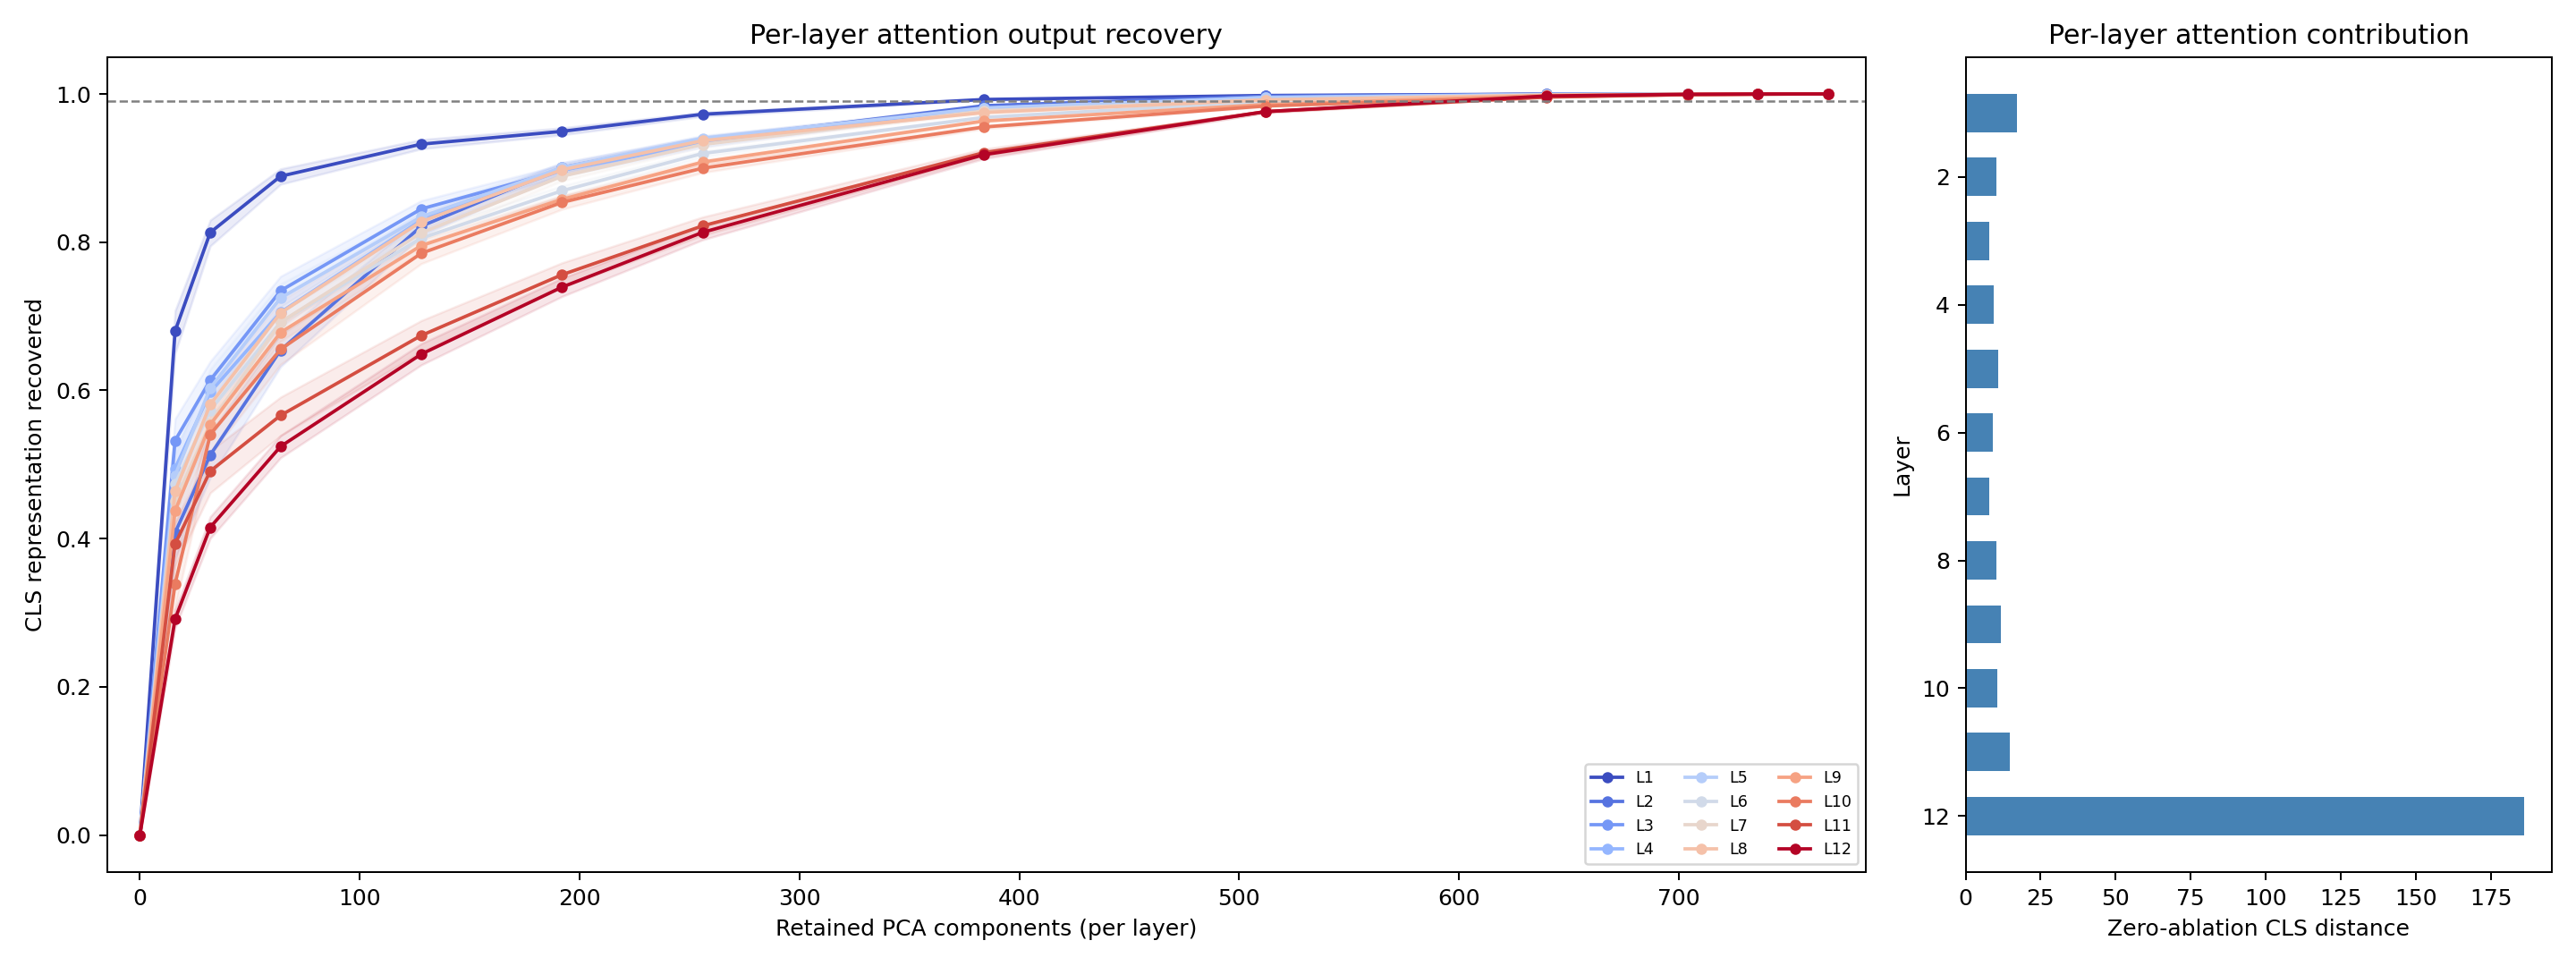

In [10]:
# 10. 逐层 attention output CLS 表征恢复
# 对每一层的 attention output 做 SVD 投影消融, 测量 CLS pooled representation
# 与基线的 L2 距离变化; PCA 样本与评估研报按 report_id/text hash 隔离。
from IPython.display import Image

from src.activation_rank_loss_recovery import run_loss_recovery_stage

LOSS_RECOVERY_POLICY = ROOT / 'configs' / 'activation_rank_loss_recovery.yaml'
loss_recovery_dir = run_loss_recovery_stage(config, LOSS_RECOVERY_POLICY)

loss_recovery_manifest = json.loads(
    (loss_recovery_dir / 'manifest.json').read_text(encoding='utf-8')
)
loss_recovery_summary = pd.read_parquet(loss_recovery_dir / 'site_summary.parquet')
loss_recovery_metrics = pd.read_parquet(
    loss_recovery_dir / 'loss_recovery_metrics.parquet'
)

display({
    'output': str(loss_recovery_dir),
    'loss_semantics': loss_recovery_manifest['loss_semantics'],
    'intervention_scope': loss_recovery_manifest['intervention_scope'],
    'layers': loss_recovery_manifest['layers'],
    'kinds': loss_recovery_manifest['kinds'],
    'evaluation_reports': loss_recovery_manifest['evaluation_reports'],
    'batch_size': loss_recovery_manifest['batch_size'],
    'pca_sample_report_overlap': loss_recovery_manifest['pca_sample_report_overlap'],
    'pca_sample_text_hash_overlap': loss_recovery_manifest['pca_sample_text_hash_overlap'],
})
display(loss_recovery_summary)
display(
    loss_recovery_metrics.loc[
        loss_recovery_metrics['n_components'].isin([0, 64, 128, 256, 384, 512, 768]),
        [
            'site', 'layer', 'n_components', 'distance_zero',
            'distance_projected', 'status', 'recovery_fraction',
            'recovery_ci_lower', 'recovery_ci_upper',
        ],
    ]
)
display(Image(filename=str(loss_recovery_dir / 'loss_recovery.png')))

In [11]:
# 11. 消融实验：所有层同时消融 — 排除"后层修复前层"假说
# 方案1: 所有12层同时消融, 统一 K = max(各层单层99%恢复所需K)
# 方案2: 所有12层同时消融, 扫描K网格, 画全层恢复曲线 vs 单层曲线
from contextlib import ExitStack
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.activation_rank_loss_recovery import (
    _load_candidate, _tokenize_evaluation, resolve_projection_module,
    SingleSiteProjection, select_disjoint_evaluation_reports,
    load_loss_recovery_policy,
)
from src.activation_rank import _model_paths, _mapping, _read_report_texts, _run_directory

# --- 从 cell 10 结果读取各层 K_99 ---
k99_per_layer = loss_recovery_summary.set_index('layer')['n_sustained_recovery'].dropna().astype(int).to_dict()
k_unified = max(k99_per_layer.values())
print('各层单层 99% 恢复所需 K:')
for l in sorted(k99_per_layer):
    print(f'  Layer {l:2d}: K_99 = {k99_per_layer[l]}')
print(f'\n方案1 统一 K = max(K_99) = {k_unified}')

# --- 加载模型 + 评估数据 (与 cell 10 一致) ---
run_dir = _run_directory(config)
base, checkpoint = _model_paths(config)
device = str(_mapping(config, 'model').get('device', 'cuda:1'))
pilot_manifest = json.loads((run_dir / 'pilot' / 'manifest.json').read_text(encoding='utf-8'))
dtype_name = pilot_manifest['selected_compute_dtype']
candidate, tokenizer = _load_candidate(base=base, checkpoint=checkpoint, device=device, dtype_name=dtype_name)

policy = load_loss_recovery_policy(ROOT / 'configs' / 'activation_rank_loss_recovery.yaml')
reports = _read_report_texts(config)
rank_sample = pd.read_parquet(run_dir / 'sample' / 'sample_manifest.parquet')
selected = select_disjoint_evaluation_reports(
    reports, rank_sample,
    report_count=int(policy['evaluation']['report_count']),
    order_seed=str(policy['evaluation']['order_seed']),
)
encoded = _tokenize_evaluation(tokenizer, selected, int(_mapping(config, 'model').get('max_length', 512)))

# SVD 基 (12 层各有自己的主成分矩阵)
sub = np.load(run_dir / 'analysis' / 'subspaces.npz', allow_pickle=False)
all_layers = list(range(1, 13))
bases = {f'attention_output_{l:02d}': sub[f'token_natural_filtered__attention_output_{l:02d}__eigenvectors'] for l in all_layers}
modules = [(l, resolve_projection_module(candidate.bert, f'attention_output_{l:02d}')) for l in all_layers]

# 基线 CLS
baseline_parts = []
with torch.inference_mode():
    for start in range(0, len(selected), 256):
        stop = min(start + 256, len(selected))
        inputs = {k: v[start:stop].pin_memory().to(device, non_blocking=True) for k, v in encoded.items()}
        out = candidate(**inputs)
        baseline_parts.append(out.pooled_feature.float().cpu())
baseline_cls = torch.cat(baseline_parts, dim=0)

def all_layer_distance(k):
    """同时消融所有12层 attention output 到 k 维, 返回平均 CLS L2 距离."""
    with ExitStack() as stack:
        if k < 768:
            for layer, module in modules:
                site = f'attention_output_{layer:02d}'
                stack.enter_context(SingleSiteProjection(module, bases[site], k))
        with torch.inference_mode():
            parts = []
            for start in range(0, len(selected), 256):
                stop = min(start + 256, len(selected))
                inputs = {key: v[start:stop].pin_memory().to(device, non_blocking=True) for key, v in encoded.items()}
                out = candidate(**inputs)
                parts.append(out.pooled_feature.float().cpu())
    modified_cls = torch.cat(parts, dim=0)
    distances = ((modified_cls - baseline_cls) ** 2).sum(dim=1)
    return float(distances.mean().item())

# 零消融基准 (所有层同时清零)
dist_zero_all = all_layer_distance(0)
print(f'\n所有层同时零消融 distance = {dist_zero_all:.4f}')

# --- 方案1: 统一 K = max(K_99) ---
dist_k_unified = all_layer_distance(k_unified)
recovery_scheme1 = 1 - dist_k_unified / dist_zero_all
print(f'\n=== 方案1: 所有层统一 K={k_unified} ===')
print(f'  distance = {dist_k_unified:.4f}, recovery = {recovery_scheme1:.1%}')

# --- 方案2: K 网格 ---
k_grid = [0, 16, 32, 64, 128, 192, 256, 384, 512, 640, 704, 736, 768]
scheme2 = []
for k in k_grid:
    d = all_layer_distance(k)
    r = 1 - d / dist_zero_all if dist_zero_all > 0 else float('nan')
    scheme2.append({'k': k, 'distance': round(d, 4), 'recovery': round(r, 4)})
    print(f'  K={k:3d}: distance={d:.4f}, recovery={r:.1%}')
scheme2_df = pd.DataFrame(scheme2)

# --- 画图 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: 方案2 全层恢复曲线
ax1.plot(scheme2_df['k'], scheme2_df['recovery'], 'o-', linewidth=2, markersize=6, color='darkred', label='All 12 layers simultaneous')
ax1.axhline(0.99, color='gray', linestyle='--', alpha=0.5, label='99% recovered')
ax1.axvline(k_unified, color='red', linestyle=':', alpha=0.7, label=f'K_unified={k_unified}')
# 叠加各单层曲线做对比
colors = plt.cm.coolwarm(np.linspace(0, 1, 12))
for layer in all_layers:
    single = loss_recovery_metrics[loss_recovery_metrics['layer'] == layer].sort_values('n_components')
    ax1.plot(single['n_components'], single['recovery_fraction'], '-', color=colors[layer-1], alpha=0.2, linewidth=0.8)
ax1.set_xlabel('K (components per layer)')
ax1.set_ylabel('CLS representation recovered')
ax1.set_title('Scheme 2: All-layer simultaneous vs single-layer')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.05)

# 右: 方案1 对比柱状图 (在 K=K_unified 处)
single_at_k = loss_recovery_metrics[
    loss_recovery_metrics['n_components'] == k_unified
][['layer', 'recovery_fraction']].sort_values('layer')
ax2.bar(single_at_k['layer'], single_at_k['recovery_fraction'], alpha=0.5, color='steelblue', label='Single-layer ablation')
ax2.bar([13], [recovery_scheme1], alpha=0.7, color='darkred', label='All 12 layers simultaneous')
ax2.axhline(0.99, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Layer (13 = all simultaneous)')
ax2.set_ylabel(f'Recovery at K={k_unified}')
ax2.set_title(f'Scheme 1: Single vs All-layer at K={k_unified}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

display(scheme2_df)

各层单层 99% 恢复所需 K:
  Layer  1: K_99 = 384
  Layer  2: K_99 = 512
  Layer  3: K_99 = 512
  Layer  4: K_99 = 512
  Layer  5: K_99 = 512
  Layer  6: K_99 = 640
  Layer  7: K_99 = 512
  Layer  8: K_99 = 512
  Layer  9: K_99 = 640
  Layer 10: K_99 = 640
  Layer 11: K_99 = 640
  Layer 12: K_99 = 640

方案1 统一 K = max(K_99) = 640



所有层同时零消融 distance = 185.6358

=== 方案1: 所有层统一 K=640 ===
  distance = 0.7552, recovery = 99.6%
  K=  0: distance=185.6358, recovery=0.0%
  K= 16: distance=145.7003, recovery=21.5%
  K= 32: distance=124.5995, recovery=32.9%
  K= 64: distance=102.2275, recovery=44.9%
  K=128: distance=77.9031, recovery=58.0%
  K=192: distance=58.8070, recovery=68.3%
  K=256: distance=42.4339, recovery=77.1%
  K=384: distance=18.5506, recovery=90.0%
  K=512: distance=5.6022, recovery=97.0%
  K=640: distance=0.7552, recovery=99.6%
  K=704: distance=0.1405, recovery=99.9%
  K=736: distance=0.0356, recovery=100.0%
  K=768: distance=0.0000, recovery=100.0%


,k,distance,recovery
0,0,185.6358,0.0000
1,16,145.7003,0.2151
2,32,124.5995,0.3288
3,64,102.2275,0.4493
4,128,77.9031,0.5803
5,192,58.8070,0.6832
6,256,42.4339,0.7714
7,384,18.5506,0.9001
8,512,5.6022,0.9698
9,640,0.7552,0.9959


{'output': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/gubapost_v1/extensions/attention_subspace_coverage_v1',
 'scope': 'descriptive_attention_write_space_geometry',
 'k_grid': [64, 128, 256, 384, 512, 640],
 'primary_k': 256,
 'layers': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'random_overlap_formula': 'K / 768',
 'labels_or_returns_loaded': False}

,orthogonal_error,symmetry_error,projector_idempotency_error,trace_error,orthogonal_passed,symmetry_passed,projector_passed,trace_passed,k
0,1.432767e-08,0.0,1.056288e-08,5.046714e-08,True,True,True,True,64
1,1.432767e-08,0.0,1.284418e-08,2.133126e-08,True,True,True,True,128
2,1.432767e-08,0.0,1.417405e-08,3.468244e-08,True,True,True,True,256
3,1.432767e-08,0.0,1.522044e-08,1.033811e-08,True,True,True,True,384
4,1.432767e-08,0.0,1.537894e-08,3.695925e-08,True,True,True,True,512
5,1.432767e-08,0.0,1.581598e-08,9.245014e-10,True,True,True,True,640


,effective_coverage_rank,directions_coverage_below_005,directions_coverage_below_010,directions_coverage_above_050,directions_coverage_above_090,coverage_eigenvalue_min,coverage_eigenvalue_max,coverage_eigenvalue_mean,k,prefix_layers
0,343.82,451,562,10,0,0.000000,0.591028,0.083333,64,12
1,493.04,234,375,51,0,0.002163,0.696128,0.166667,128,12
2,631.88,2,91,186,0,0.008074,0.815383,0.333333,256,12
3,698.90,1,1,380,0,0.017751,0.891915,0.500000,384,12
4,736.12,1,1,594,67,0.035952,0.948741,0.666667,512,12
5,757.21,0,1,761,318,0.090656,0.990202,0.833333,640,12


,layer_i,layer_j,layer_distance,overlap,random_overlap_baseline,excess_overlap
327,4,4,0,1.000000,0.333333,0.666667
314,3,3,0,1.000000,0.333333,0.666667
418,11,11,0,1.000000,0.333333,0.666667
288,1,1,0,1.000000,0.333333,0.666667
301,2,2,0,1.000000,0.333333,0.666667
405,10,10,0,1.000000,0.333333,0.666667
431,12,12,0,1.000000,0.333333,0.666667
392,9,9,0,1.000000,0.333333,0.666667
366,7,7,0,1.000000,0.333333,0.666667
379,8,8,0,1.000000,0.333333,0.666667


,k,prefix_layers,effective_coverage_rank,directions_coverage_below_005,directions_coverage_above_050
0,64,1,64.00,704,64
1,64,2,101.00,646,64
2,64,3,132.13,608,59
3,64,4,155.14,584,52
4,64,5,187.52,556,45
...,...,...,...,...,...
67,640,8,751.93,0,728
68,640,9,753.17,0,734
69,640,10,754.32,0,742
70,640,11,755.74,0,750


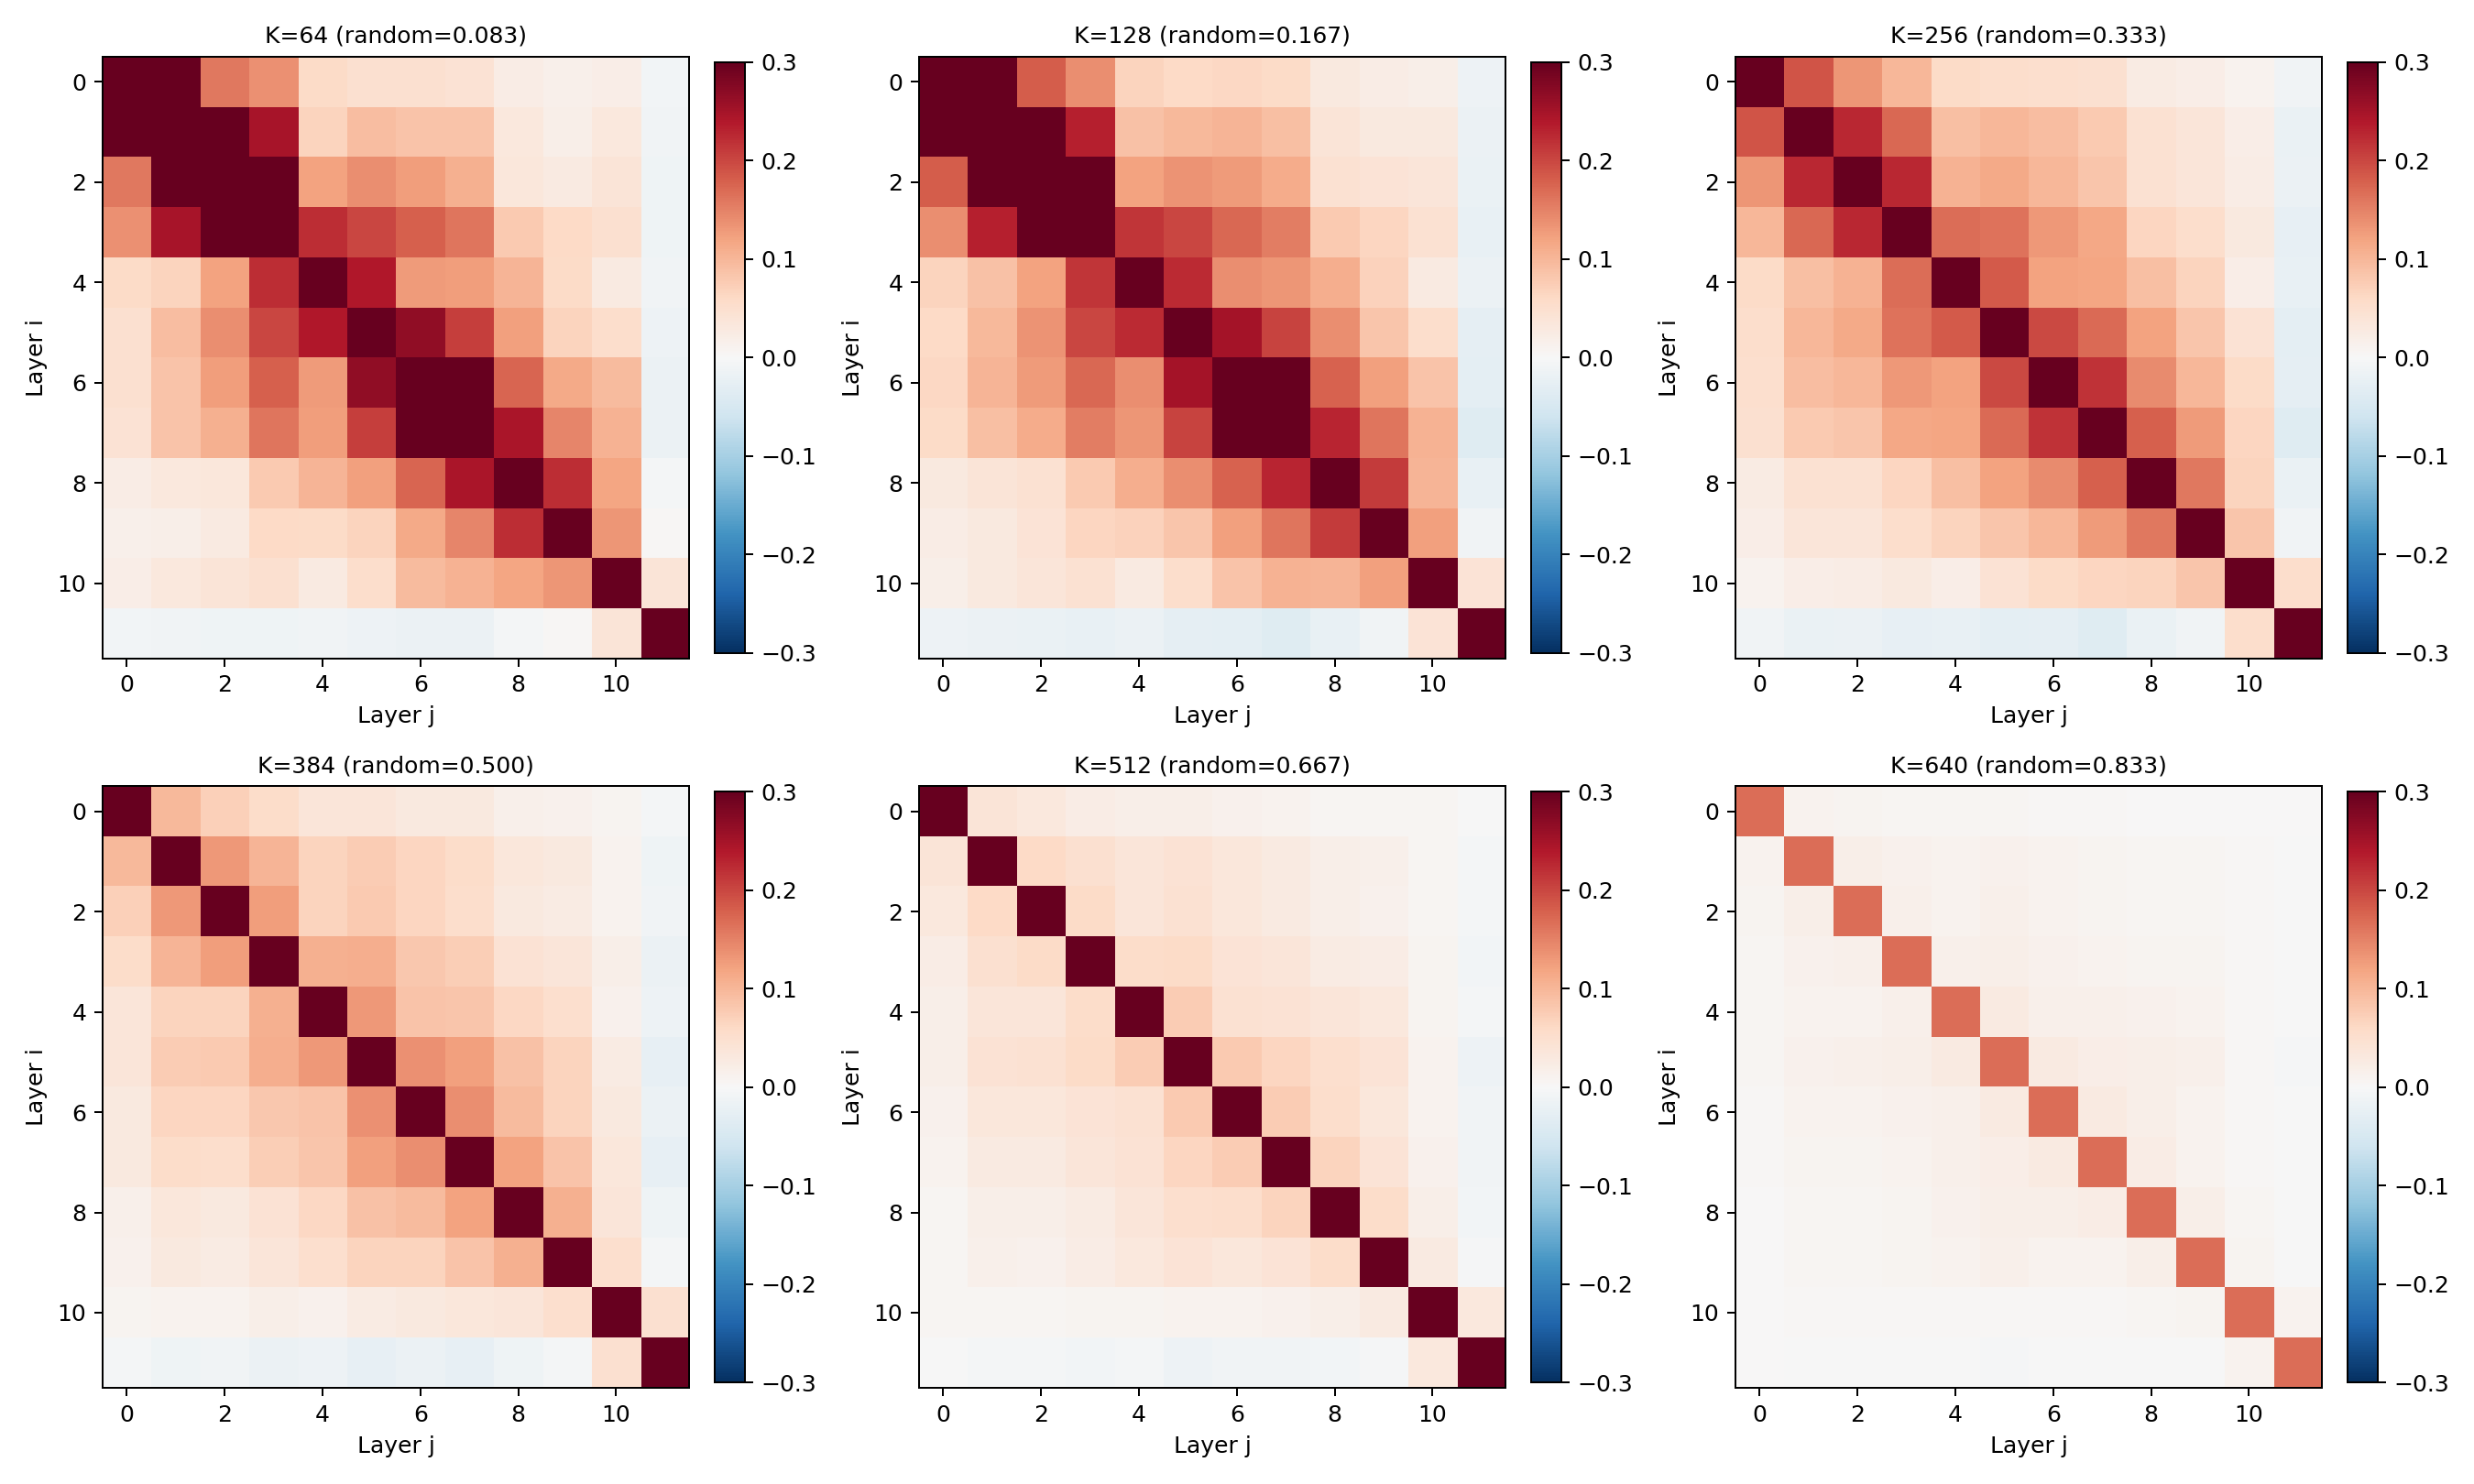

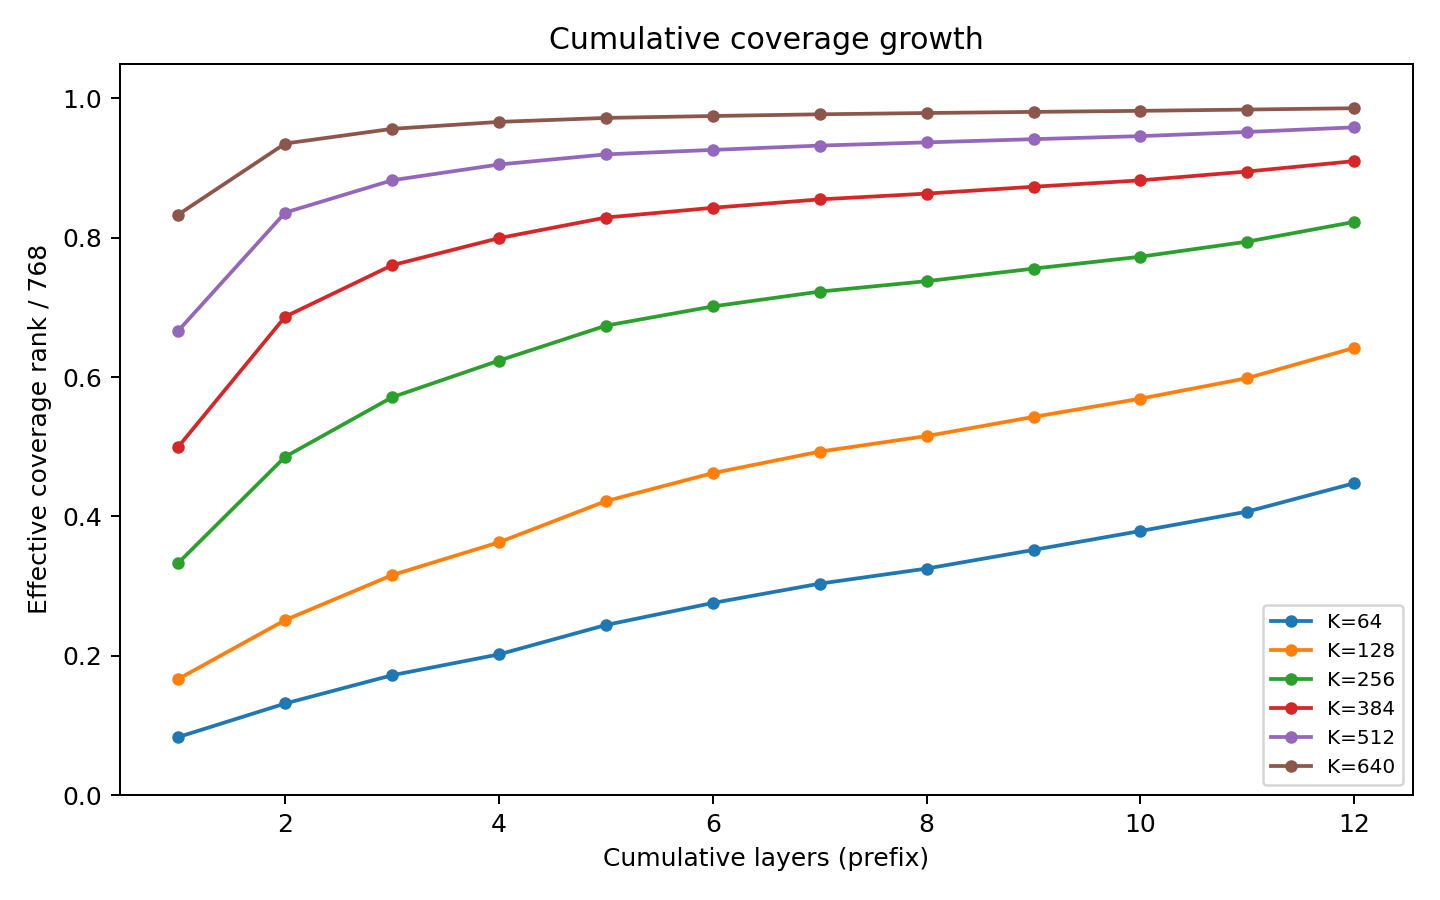

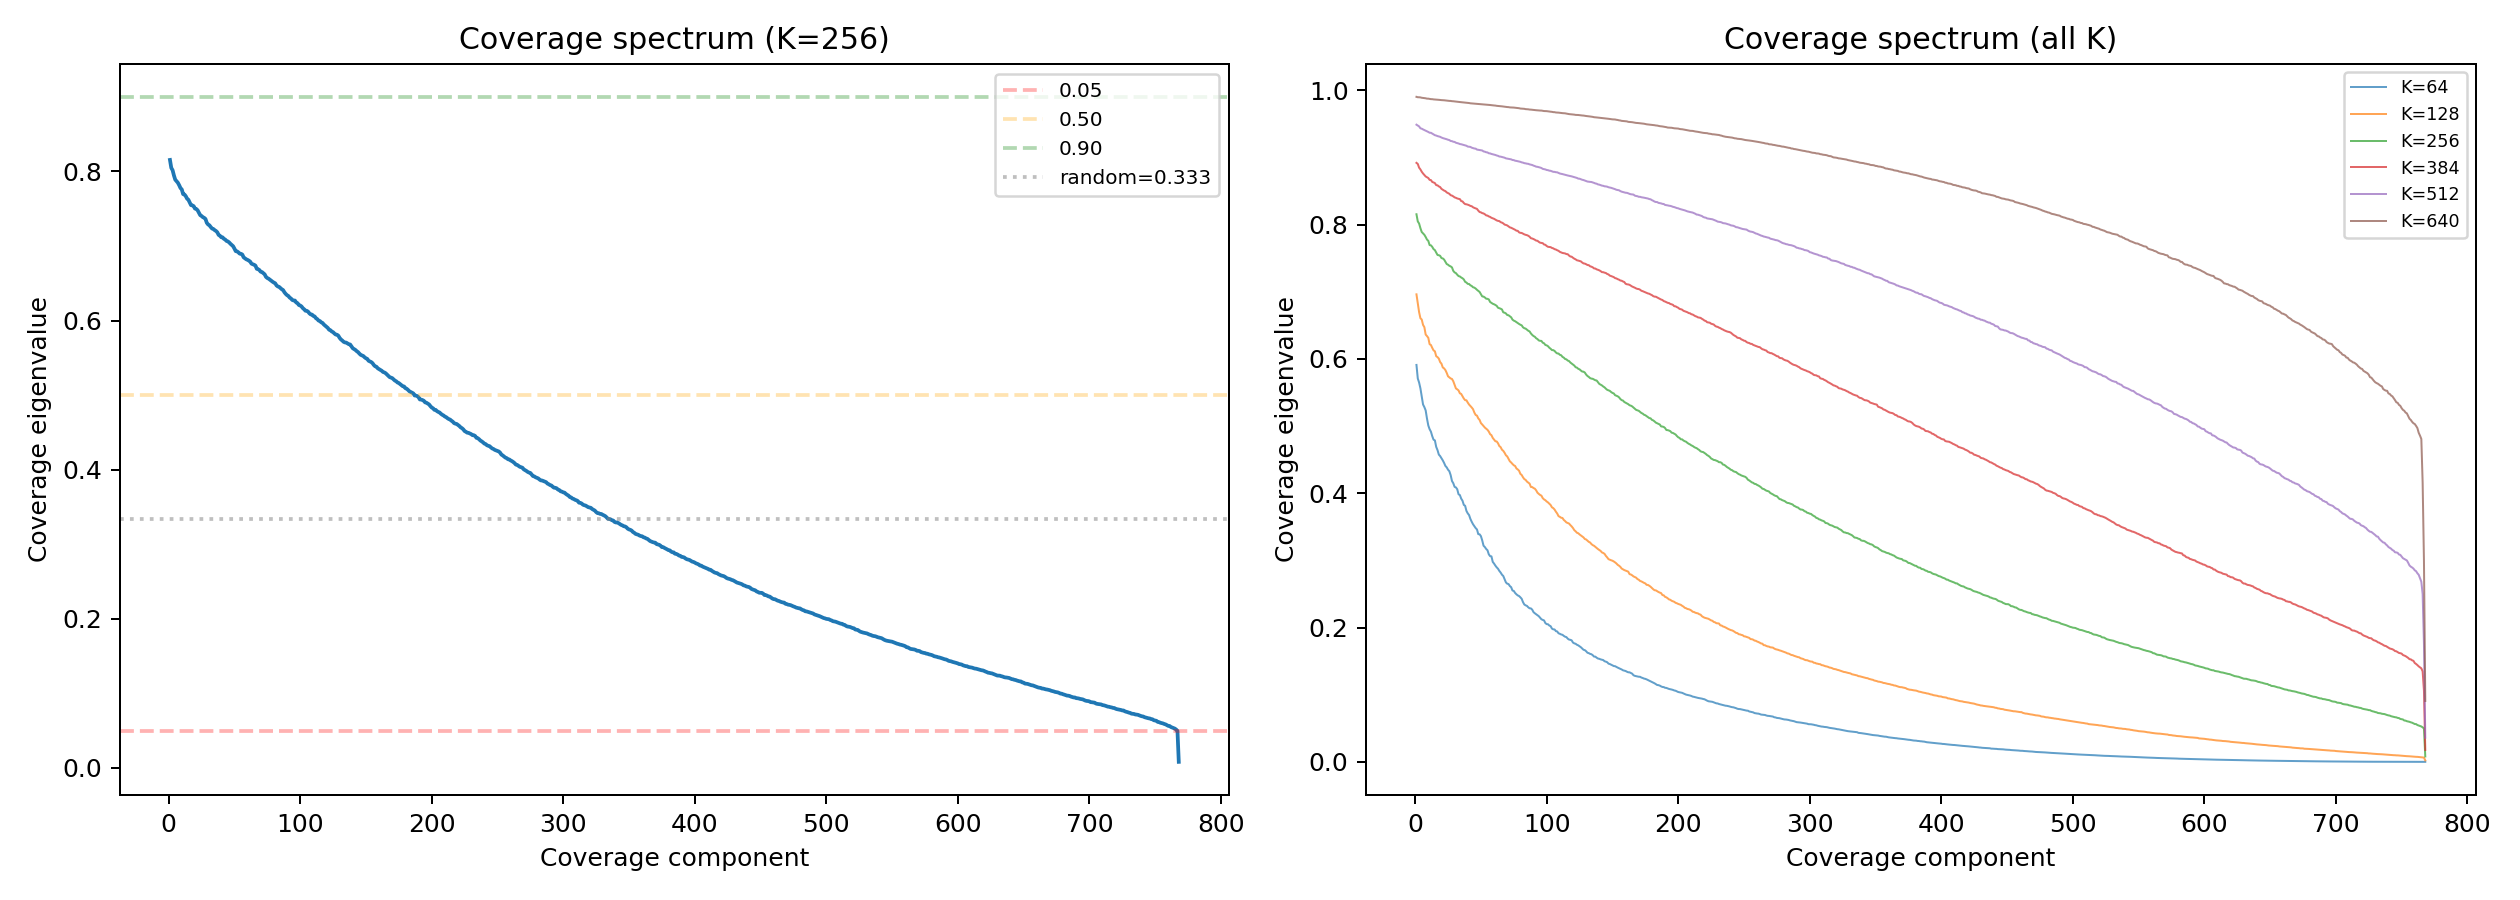

: 

In [ ]:
# 12. Attention output 写入子空间覆盖分析
# 纯线性代数: 各层 top-K 子空间的重合度、累计覆盖谱、低覆盖方向
# 不加载模型, 不读取标签, 仅复用上游 SVD 结果
from IPython.display import Image

from src.activation_subspace_coverage import run_coverage_stage

COVERAGE_POLICY = ROOT / 'configs' / 'activation_subspace_coverage.yaml'
coverage_dir = run_coverage_stage(config, COVERAGE_POLICY)

coverage_manifest = json.loads(
    (coverage_dir / 'manifest.json').read_text(encoding='utf-8')
)
pairwise_df = pd.read_parquet(coverage_dir / 'pairwise_overlap.parquet')
cumulative_df = pd.read_parquet(coverage_dir / 'cumulative_coverage.parquet')
eigvals_df = pd.read_parquet(coverage_dir / 'coverage_eigenvalues.parquet')
summary_df = pd.read_parquet(coverage_dir / 'coverage_summary.parquet')
invariants_df = pd.read_parquet(coverage_dir / 'numerical_invariants.parquet')

display({
    'output': str(coverage_dir),
    'scope': coverage_manifest['scope'],
    'k_grid': coverage_manifest['k_grid'],
    'primary_k': coverage_manifest['primary_k'],
    'layers': coverage_manifest['layers'],
    'random_overlap_formula': coverage_manifest['random_overlap_formula'],
    'labels_or_returns_loaded': coverage_manifest['labels_or_returns_loaded'],
})

# 数值不变量
display(invariants_df)

# 各 K 的 coverage summary
display(summary_df)

# 关键: K=256 (primary) 的 pairwise excess overlap
pk = summary_df['k'].min()  # primary_k from config
primary_k = coverage_manifest['primary_k']
excess_at_pk = pairwise_df[
    pairwise_df['k'] == primary_k
][['layer_i', 'layer_j', 'layer_distance', 'overlap',
    'random_overlap_baseline', 'excess_overlap']].sort_values(
    'excess_overlap', ascending=False)
display(excess_at_pk.head(20))

# 累计覆盖增长
display(cumulative_df[['k', 'prefix_layers', 'effective_coverage_rank',
    'directions_coverage_below_005', 'directions_coverage_above_050']])

# 三张图
display(Image(filename=str(coverage_dir / 'pairwise_overlap_heatmap.png')))
display(Image(filename=str(coverage_dir / 'cumulative_coverage.png')))
display(Image(filename=str(coverage_dir / 'coverage_spectrum.png')))